In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("statistic_store_benchmark.csv")
df['throughput'] = df['num_statistics'] / (df['duration_ms'] / 1000)

# All possible benchmark parameters (excluding benchmark, store_type, repetition, duration_ms)
ALL_PARAMS = ['num_threads', 'num_statistics', 'num_statistic_ids', 'statistic_size',
              'window_size', 'pct_access_existing', 'pct_insert', 'num_statistics_per_request', 'pct_pre_populate']

df

,benchmark,store_type,num_threads,num_statistics,num_statistic_ids,statistic_size,window_size,pct_access_existing,num_statistics_per_request,pct_insert,pct_pre_populate,random_seed,repetition,duration_ms,throughput
0,InsertStatistic,DEFAULT,1,10000000,1,1024,60000,-1,-1,-1,-1,820511531,0,635.02000,1.574754e+07
1,InsertStatistic,DEFAULT,1,10000000,1,1024,60000,-1,-1,-1,-1,820511531,1,629.80300,1.587798e+07
2,InsertStatistic,DEFAULT,1,10000000,1,1024,60000,-1,-1,-1,-1,820511531,2,626.41600,1.596383e+07
3,InsertStatistic,DEFAULT,4,10000000,1,1024,60000,-1,-1,-1,-1,820511531,0,918.21000,1.089075e+07
4,InsertStatistic,DEFAULT,4,10000000,1,1024,60000,-1,-1,-1,-1,820511531,1,948.41300,1.054393e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,GetStatistics,WINDOW,16,100000,1000,1024,1000,100,10,-1,-1,820511531,1,7.06737,1.414954e+07
509,GetStatistics,WINDOW,16,100000,1000,1024,1000,100,10,-1,-1,820511531,2,7.06318,1.415793e+07
510,GetStatistics,WINDOW,16,100000,1000,1024,1000,100,100,-1,-1,820511531,0,58.79810,1.700735e+06
511,GetStatistics,WINDOW,16,100000,1000,1024,1000,100,100,-1,-1,820511531,1,43.72110,2.287225e+06


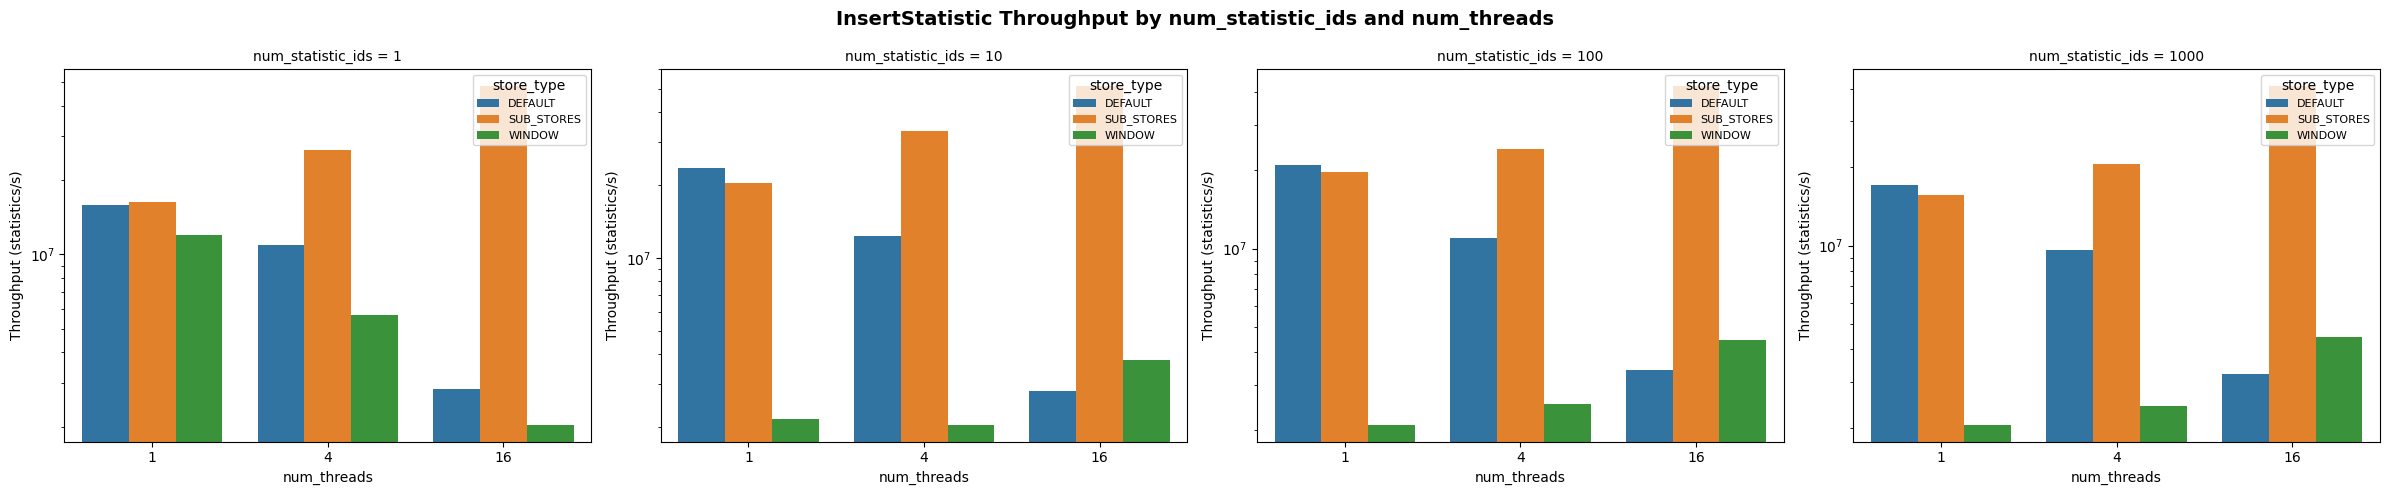

In [2]:
# Insert benchmark: throughput vs num_threads, one subplot per num_statistic_ids
%matplotlib inline

benchmark = 'InsertStatistic'
df_bm = df[df['benchmark'] == benchmark].copy()

if df_bm.empty:
    print(f"No data for {benchmark}")
else:
    relevant = [p for p in ALL_PARAMS if not (df_bm[p] == -1).all()]

    if 'num_statistic_ids' not in relevant or 'num_threads' not in relevant:
        print(f"Skipping {benchmark}: 'num_statistic_ids' or 'num_threads' not found in relevant parameters.")
    else:
        group_cols = ['store_type', 'num_statistic_ids', 'num_threads']
        df_avg = df_bm.groupby(group_cols, as_index=False)[['throughput']].mean()
        df_std = df_bm.groupby(group_cols, as_index=False)[['throughput']].std()
        df_plot = pd.merge(df_avg, df_std, on=group_cols, suffixes=('_mean', '_std'))

        num_statistic_ids_values = sorted(df_plot['num_statistic_ids'].unique())
        n = len(num_statistic_ids_values)

        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)

        for i, num_stat in enumerate(num_statistic_ids_values):
            subset = df_plot[df_plot['num_statistic_ids'] == num_stat]

            ax = axes[0][i]
            sns.barplot(
                data=subset,
                x='num_threads',
                y='throughput_mean',
                hue='store_type',
                ax=ax,
                capsize=0.1,
                err_kws={'linewidth': 1.5},
            )
            ax.set_yscale('log')
            ax.set_xlabel('num_threads')
            ax.set_ylabel('Throughput (statistics/s)')
            ax.set_title(f'num_statistic_ids = {num_stat}', fontsize=10)
            ax.legend(title='store_type', fontsize=8, loc='upper right')

        fig.suptitle(f'{benchmark} Throughput by num_statistic_ids and num_threads', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"{benchmark}_Throughput_Bars_WithErrorBars.pdf", dpi=300, bbox_inches="tight")
        plt.show()

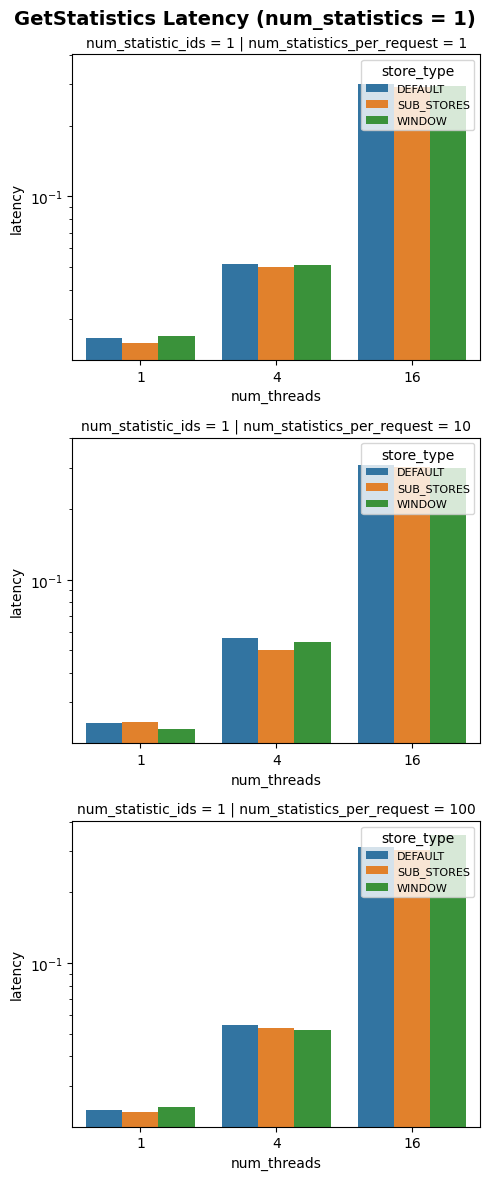

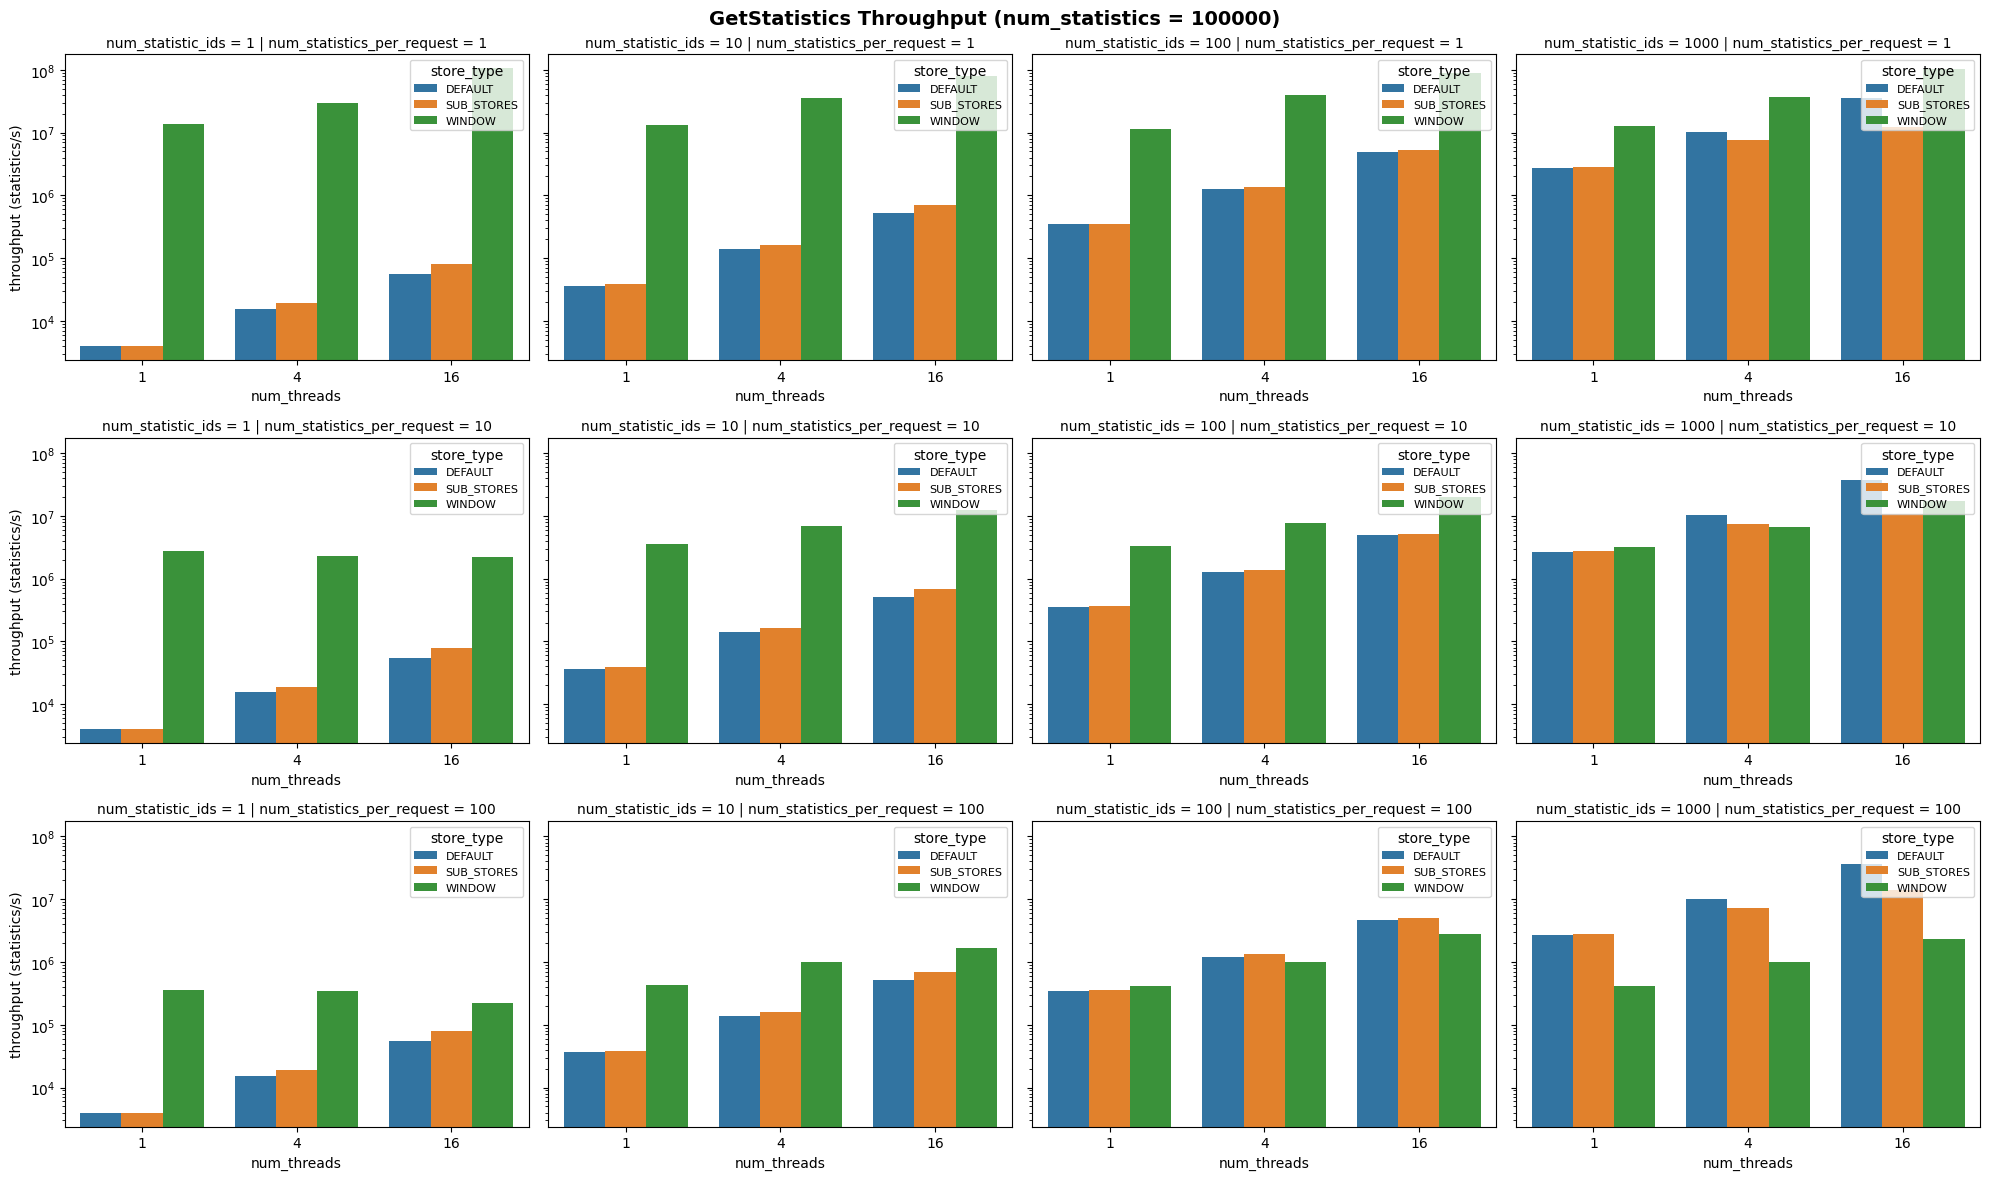

In [3]:
# Get benchmark: plot latency only for num_statistics == 1, throughput for all other num_statistics values.
# Each figure: grid with cols=num_statistic_ids, rows=num_statistics_per_request.
# Within each subplot: metric (y) vs num_threads (x), grouped by store_type.
%matplotlib inline

benchmark = 'GetStatistics'
df_bm = df[df['benchmark'] == benchmark].copy()

if df_bm.empty:
    print(f"No data for {benchmark}")
else:
    # Latency per request in ms; num_statistics is the total number of get requests issued.
    df_bm['latency_ms'] = df_bm['duration_ms'] / df_bm['num_statistics']

    group_cols = ['store_type', 'num_statistics', 'num_statistic_ids', 'num_statistics_per_request', 'num_threads']
    df_avg = df_bm.groupby(group_cols, as_index=False)[['latency_ms', 'throughput']].mean()
    df_std = df_bm.groupby(group_cols, as_index=False)[['latency_ms', 'throughput']].std()
    df_plot = pd.merge(df_avg, df_std, on=group_cols, suffixes=('_mean', '_std'))

    num_statistics_values = sorted(df_plot['num_statistics'].unique())

    LATENCY_METRIC = ('latency_ms', 'latency', 'Latency')
    THROUGHPUT_METRIC = ('throughput', 'throughput (statistics/s)', 'Throughput')

    for num_statistics in num_statistics_values:
        df_ns = df_plot[df_plot['num_statistics'] == num_statistics]

        col_values = sorted(df_ns['num_statistic_ids'].unique())
        row_values = sorted(df_ns['num_statistics_per_request'].unique())
        n_cols = len(col_values)
        n_rows = len(row_values)

        metrics = [LATENCY_METRIC] if num_statistics == 1 else [THROUGHPUT_METRIC]

        for metric_key, y_label, metric_title in metrics:
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False, sharey=True)

            for r, row_val in enumerate(row_values):
                for c, col_val in enumerate(col_values):
                    ax = axes[r][c]
                    subset = df_ns[
                        (df_ns['num_statistic_ids'] == col_val)
                        & (df_ns['num_statistics_per_request'] == row_val)
                    ]

                    if subset.empty:
                        ax.set_visible(False)
                        continue

                    sns.barplot(
                        data=subset,
                        x='num_threads',
                        y=f'{metric_key}_mean',
                        hue='store_type',
                        ax=ax,
                        capsize=0.1,
                        err_kws={'linewidth': 1.5},
                    )
                    ax.set_yscale('log')
                    ax.set_xlabel('num_threads')
                    ax.set_ylabel(y_label)
                    ax.set_title(
                        f'num_statistic_ids = {col_val} | num_statistics_per_request = {row_val}',
                        fontsize=10,
                    )
                    ax.legend(title='store_type', fontsize=8, loc='upper right')

            fig.suptitle(
                f'{benchmark} {metric_title} (num_statistics = {num_statistics})',
                fontsize=14,
                fontweight='bold',
            )
            plt.tight_layout()
            plt.savefig(
                f"{benchmark}_{metric_title}_numStatistics{num_statistics}.pdf",
                dpi=300,
                bbox_inches="tight",
            )
            plt.show()